In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (10, 6)

In [ ]:
"""
=============================================================
STEP 4 (DEFINITIVE): Behaviour Clustering using Paper Features
=============================================================
Uses exactly the 6 normalised features from Table 1 of the paper:
  X1 = std_sog / 10
  X2 = detour (min-max normalised)
  X3 = drift_angle × π/180
  X4 = accum_cog × π/180
  X5 = delta_cog × π/180
  X6 = max_lat / route_width

Approach:
  1. Elbow + Silhouette to find natural k
  2. KMeans with best k (no threshold-based clustering)
  3. Map clusters to 4 behaviour types by centroid characteristics
  4. Class 5 = segments that are statistical outliers (IQR method)
=============================================================
"""

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster        import KMeans
from sklearn.preprocessing  import MinMaxScaler
from sklearn.metrics        import silhouette_score, davies_bouldin_score
from scipy                  import stats
import matplotlib.pyplot    as plt
import matplotlib
matplotlib.use('Agg')

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
SEGMENTS_PATH = "/content/drive/MyDrive/AIS_reduced/abnormal_segments_v2.csv"
KDE_PATH      = "/content/drive/MyDrive/AIS_reduced/ais_mahal_flagged.csv"
OUTPUT_DIR    = "/content/drive/MyDrive/AIS_reduced"
PLOT_DIR      = "/content/drive/MyDrive/AIS_reduced/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,   exist_ok=True)
RANDOM_STATE  = 42

# ─────────────────────────────────────────────────────────────
# HELPERS — recompute paper features cleanly
# ─────────────────────────────────────────────────────────────

def haversine_path(lats, lons):
    R = 6371.0
    total = 0.0
    for i in range(len(lats)-1):
        la1,lo1 = np.radians(lats[i]),   np.radians(lons[i])
        la2,lo2 = np.radians(lats[i+1]), np.radians(lons[i+1])
        dlat,dlon = la2-la1, lo2-lo1
        a = np.sin(dlat/2)**2 + np.cos(la1)*np.cos(la2)*np.sin(dlon/2)**2
        total += 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))
    return total

def haversine_pt(lat1,lon1,lat2,lon2):
    R = 6371.0
    la1,lo1 = np.radians(lat1), np.radians(lon1)
    la2,lo2 = np.radians(lat2), np.radians(lon2)
    a = np.sin((la2-la1)/2)**2 + np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))

# ─────────────────────────────────────────────────────────────
# STEP 1: Load
# ─────────────────────────────────────────────────────────────
print("="*60)
print("STEP 1: Loading data...")
print("="*60)
seg_df = pd.read_csv(SEGMENTS_PATH)
seg_df['t_start'] = pd.to_datetime(seg_df['t_start'])
seg_df['t_end']   = pd.to_datetime(seg_df['t_end'])
print(f"  Segments : {len(seg_df):,} | {seg_df['MMSI'].nunique()} ships")

kde_df = pd.read_csv(KDE_PATH)
kde_df['BaseDateTime'] = pd.to_datetime(kde_df['BaseDateTime'])
kde_df = kde_df.sort_values(['MMSI','BaseDateTime']).reset_index(drop=True)
print(f"  KDE data : {len(kde_df):,} rows")

# ─────────────────────────────────────────────────────────────
# STEP 2: Recompute the 6 paper features per segment
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 2: Computing paper Table 1 features per segment...")
print("="*60)

records = []
for _, row in seg_df.iterrows():
    mmsi    = row['MMSI']
    t_start = row['t_start']
    t_end   = row['t_end']

    mask = ((kde_df['MMSI']==mmsi) &
            (kde_df['BaseDateTime']>=t_start) &
            (kde_df['BaseDateTime']<=t_end))
    pts = kde_df[mask].sort_values('BaseDateTime')

    if len(pts) < 3:
        continue

    sog    = pts['SOG'].values.astype(float)
    cog    = pts['COG'].values.astype(float)
    lats   = pts['LAT'].values.astype(float)
    lons   = pts['LON'].values.astype(float)
    lat_km = pts['lateral_dist'].values.astype(float)
    heading= pts['Heading'].values.astype(float) if 'Heading' in pts.columns else None

    # ── X1: std_sog / 10 (Table 1) ──────────────────────────
    x1 = np.std(sog) / 10.0

    # ── X2: detour factor (normalised globally later) ────────
    path     = haversine_path(lats, lons)
    geodesic = haversine_pt(lats[0],lons[0],lats[-1],lons[-1])
    x2_raw   = float(np.clip(path/(geodesic+1e-6), 1.0, 50.0))

    # ── X3: max drift angle × π/180 ─────────────────────────
    if heading is not None and not np.all(np.isnan(heading)):
        valid = ~np.isnan(heading)
        if valid.sum() > 1:
            diff = np.abs(cog[valid] - heading[valid])
            diff = np.where(diff>180, 360-diff, diff)
            x3   = float(np.max(diff)) * np.pi/180
        else:
            x3 = float(np.std(cog)) * np.pi/180
    else:
        x3 = float(np.std(cog)) * np.pi/180
    x3 = float(np.clip(x3, 0, np.pi))

    # ── X4: accumulative COG change × π/180 (Eq.6) ──────────
    # Paper: sum of |COG_{i+1} - COG_i| in degrees, then × π/180
    cog_diff   = np.abs(np.diff(cog))
    cog_diff   = np.where(cog_diff>180, 360-cog_diff, cog_diff)  # wrap
    accum_deg  = float(np.sum(cog_diff))
    x4         = accum_deg * np.pi / 180.0   # now in radians total
    # Circular ~ 2π total per revolution, but long segments accumulate more
    # Normalise by segment length (points) to make comparable
    x4_per_pt  = x4 / max(len(cog)-1, 1)    # radians per step

    # ── X5: delta COG × π/180 ───────────────────────────────
    diff_cog = abs(float(cog[-1]) - float(cog[0]))
    diff_cog = min(diff_cog, 360-diff_cog)
    x5 = diff_cog * np.pi / 180.0

    # ── X6: max lateral distance / route_width ───────────────
    lat_norm = pts['lateral_dist_norm'].values.astype(float)
    x6 = float(np.max(np.abs(lat_norm)))
    x6 = float(np.clip(x6, 0, 10.0))

    records.append({
        'seg_id'      : row['seg_id'],
        'MMSI'        : mmsi,
        't_start'     : t_start,
        't_end'       : t_end,
        'duration_min': row['duration_min'],
        'n_points'    : len(pts),
        'n_ab_points' : int(pts['ab_any'].sum()),
        # Paper features (raw before global norm)
        'X1'     : x1,
        'X2_raw' : x2_raw,
        'X3'     : x3,
        'X4'     : x4_per_pt,   # rad/step — scale invariant
        'X5'     : x5,
        'X6'     : x6,
        # Keep original normalised for RF
        'X1_std_sog'    : row['X1_std_sog'],
        'X2_detour'     : row['X2_detour'],
        'X3_drift_angle': row['X3_drift_angle'],
        'X4_accum_cog'  : row['X4_accum_cog'],
        'X5_delta_cog'  : row['X5_delta_cog'],
        'X6_max_lat'    : row['X6_max_lat'],
    })

df = pd.DataFrame(records)

# Global min-max for X2 (Table 1)
mn2, mx2 = df['X2_raw'].min(), df['X2_raw'].max()
df['X2'] = (df['X2_raw'] - mn2) / (mx2 - mn2 + 1e-9)

print(f"  Processed: {len(df):,} segments")
print(f"\n  Feature statistics (for clustering):")
print(f"  {'Feature':6s} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'Description'}")
desc = {'X1':'std_sog/10','X2':'detour(norm)','X3':'drift×π/180',
        'X4':'accum_cog/step(rad)','X5':'delta_cog(rad)','X6':'max_lat/width'}
for f in ['X1','X2','X3','X4','X5','X6']:
    v = df[f].values
    print(f"  {f:6s} {v.min():>8.4f} {v.max():>8.4f} "
          f"{v.mean():>8.4f} {v.std():>8.4f}  {desc[f]}")

# ─────────────────────────────────────────────────────────────
# STEP 3: Feature matrix for clustering
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 3: Building feature matrix...")
print("="*60)

FEAT_COLS = ['X1','X2','X3','X4','X5','X6']
X = df[FEAT_COLS].values.copy()

# MinMaxScaler → all features in [0,1] for fair Euclidean distance
scaler = MinMaxScaler()
X_sc   = scaler.fit_transform(X)
print(f"  Shape: {X_sc.shape} | All features scaled to [0,1]")

# ─────────────────────────────────────────────────────────────
# STEP 4: Elbow + Silhouette to find best k
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 4: Finding optimal k (Elbow + Silhouette)...")
print("="*60)

K_RANGE    = range(2, 9)
inertias   = []
sil_scores = []
db_scores  = []

for k in K_RANGE:
    best_km  = None
    best_in  = np.inf
    for seed in range(15):
        km = KMeans(n_clusters=k, random_state=seed, n_init=10, max_iter=500)
        km.fit(X_sc)
        if km.inertia_ < best_in:
            best_in = km.inertia_
            best_km = km
    lbl = best_km.labels_
    sil = silhouette_score(X_sc, lbl) if k>=2 else -1
    db  = davies_bouldin_score(X_sc, lbl)
    inertias.append(best_in)
    sil_scores.append(sil)
    db_scores.append(db)
    sizes = np.bincount(lbl).tolist()
    print(f"  k={k}: inertia={best_in:.1f}  sil={sil:.4f}  "
          f"DB={db:.4f}  sizes={sizes}")

# Elbow: find k where inertia reduction slows (2nd derivative)
inertia_arr = np.array(inertias)
deltas      = np.diff(inertia_arr)
delta2      = np.diff(deltas)
elbow_k     = int(K_RANGE[np.argmax(delta2) + 2])  # +2 offset for double diff

# Best silhouette
best_sil_k  = int(K_RANGE[np.argmax(sil_scores)])

print(f"\n  Elbow suggests    : k={elbow_k}")
print(f"  Best silhouette   : k={best_sil_k} (score={max(sil_scores):.4f})")

# Prefer k=4 if its silhouette is within 0.05 of best
# (paper uses exactly 4 behaviour types)
sil_at_4 = sil_scores[list(K_RANGE).index(4)]
if sil_at_4 >= max(sil_scores) - 0.08:
    chosen_k = 4
    print(f"  → Choosing k=4 (paper standard, sil={sil_at_4:.4f} within 0.08 of best)")
elif best_sil_k == elbow_k:
    chosen_k = best_sil_k
    print(f"  → Both methods agree: k={chosen_k}")
else:
    chosen_k = best_sil_k
    print(f"  → Using silhouette best: k={chosen_k}")

# Elbow plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'bo-')
axes[0].axvline(x=chosen_k, color='r', linestyle='--', label=f'k={chosen_k}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(list(K_RANGE), sil_scores, 'go-')
axes[1].axvline(x=chosen_k, color='r', linestyle='--', label=f'k={chosen_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.close()
print(f"  Elbow plot saved")

# ─────────────────────────────────────────────────────────────
# STEP 5: Final KMeans with chosen_k
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print(f"STEP 5: Final KMeans with k={chosen_k}...")
print("="*60)

best_km   = None
best_in   = np.inf
for seed in range(30):
    km = KMeans(n_clusters=chosen_k, random_state=seed, n_init=20, max_iter=1000)
    km.fit(X_sc)
    if km.inertia_ < best_in:
        best_in = km.inertia_
        best_km = km

km_labels  = best_km.labels_
sil_final  = silhouette_score(X_sc, km_labels)
db_final   = davies_bouldin_score(X_sc, km_labels)
print(f"  k={chosen_k} | inertia={best_in:.2f} | "
      f"silhouette={sil_final:.4f} | DB={db_final:.4f}")
print(f"  Cluster sizes: {np.bincount(km_labels).tolist()}")

# ─────────────────────────────────────────────────────────────
# STEP 6: Identify outliers using IQR (these become Class 5)
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 6: Identifying outliers (IQR method → Class 5)...")
print("="*60)

# A segment is an outlier if it is extreme on MULTIPLE features simultaneously
# Use Mahalanobis distance from its cluster centroid
from scipy.spatial.distance import mahalanobis

is_outlier = np.zeros(len(df), dtype=bool)

for c in range(chosen_k):
    mask    = km_labels == c
    pts_c   = X_sc[mask]
    if pts_c.shape[0] < 5:
        continue   # too small to compute covariance
    try:
        cov     = np.cov(pts_c.T)
        cov_inv = np.linalg.pinv(cov)   # pseudo-inverse for stability
        center  = pts_c.mean(axis=0)
        m_dists = np.array([mahalanobis(p, center, cov_inv) for p in pts_c])
        # Outlier if Mahalanobis distance > 95th percentile of chi2(df=k)
        threshold = np.percentile(m_dists, 95)
        outlier_within = m_dists > threshold
        idx_in_df = np.where(mask)[0]
        is_outlier[idx_in_df[outlier_within]] = True
    except Exception:
        pass

n_outliers = is_outlier.sum()
print(f"  Outliers identified (Mahalanobis >95th pct): {n_outliers} "
      f"({n_outliers/len(df)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 7: Map clusters → behaviour types
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 7: Mapping clusters to behaviour types...")
print("="*60)

cluster_ids = list(range(chosen_k))
centroids   = {}
for c in cluster_ids:
    mask = (km_labels==c) & ~is_outlier
    if mask.sum() < 2:
        mask = km_labels==c
    centroids[c] = {
        'X1': df.loc[mask,'X1'].mean(),
        'X2': df.loc[mask,'X2'].mean(),
        'X3': df.loc[mask,'X3'].mean(),
        'X4': df.loc[mask,'X4'].mean(),   # rad/step
        'X5': df.loc[mask,'X5'].mean(),   # rad
        'X6': df.loc[mask,'X6'].mean(),
        'count': int(mask.sum()),
    }

print(f"  Cluster centroids:")
print(f"  {'C':>3} {'X1_sog':>8} {'X2_det':>8} {'X3_drft':>8} "
      f"{'X4_cog/s':>9} {'X5_dlt':>8} {'X6_lat':>8} {'count':>6}")
for c,cv in centroids.items():
    print(f"  {c:>3} {cv['X1']:>8.4f} {cv['X2']:>8.4f} {cv['X3']:>8.4f} "
          f"{cv['X4']:>9.5f} {cv['X5']:>8.4f} {cv['X6']:>8.4f} {cv['count']:>6}")

print(f"\n  Paper mapping rules (Section 4.2):")
print(f"    Circular      → highest X4 (COG change/step)")
print(f"    U-turn        → highest X5 (delta COG ~π)")
print(f"    Off-route     → highest X6 (max lateral dist)")
print(f"    Double U-turn → highest X2 (detour factor)")

remaining  = list(cluster_ids)
label_map  = {}
class_names = {1:'Circular',2:'U-turn',3:'Double_U-turn',
               4:'Off-route',5:'Noise'}

# If k=4, map all 4; if k<4, some classes share or are absent
# If k>4, merge smallest into nearest class

if chosen_k >= 4:
    # Class 1: Circular → highest X4
    c = max(remaining, key=lambda x: centroids[x]['X4'])
    label_map[c] = 1; remaining.remove(c)
    print(f"\n  Cluster {c} → Class 1 Circular      [X4={centroids[c]['X4']:.5f}]")

    # Class 2: U-turn → highest X5
    c = max(remaining, key=lambda x: centroids[x]['X5'])
    label_map[c] = 2; remaining.remove(c)
    print(f"  Cluster {c} → Class 2 U-turn         [X5={centroids[c]['X5']:.4f}]")

    # Class 4: Off-route → highest X6
    c = max(remaining, key=lambda x: centroids[x]['X6'])
    label_map[c] = 4; remaining.remove(c)
    print(f"  Cluster {c} → Class 4 Off-route      [X6={centroids[c]['X6']:.4f}]")

    # Class 3: Double U-turn → remaining (highest X2)
    if remaining:
        c = max(remaining, key=lambda x: centroids[x]['X2'])
        label_map[c] = 3; remaining.remove(c)
        print(f"  Cluster {c} → Class 3 Double U-turn [X2={centroids[c]['X2']:.4f}]")

    # Any extra clusters → merge into nearest class by centroid
    for c in remaining:
        # Find closest already-mapped cluster
        best_cls = min(label_map.values(),
                       key=lambda cls: abs(centroids[c]['X4'] -
                                           centroids[
                                               [k for k,v in label_map.items() if v==cls][0]
                                           ]['X4']))
        label_map[c] = best_cls
        print(f"  Cluster {c} → Class {best_cls} {class_names[best_cls]} (merged)")

else:
    # k < 4: map available clusters, leave missing classes empty
    c = max(remaining, key=lambda x: centroids[x]['X4'])
    label_map[c] = 1; remaining.remove(c)
    if remaining:
        c = max(remaining, key=lambda x: centroids[x]['X5'])
        label_map[c] = 2; remaining.remove(c)
    if remaining:
        c = max(remaining, key=lambda x: centroids[x]['X6'])
        label_map[c] = 4; remaining.remove(c)
    for c in remaining:
        label_map[c] = 3

# Apply labels
df['km_cluster']  = km_labels
df['is_outlier']  = is_outlier
df['class_label'] = df['km_cluster'].map(label_map)
df.loc[is_outlier, 'class_label'] = 5
df['behaviour_type'] = df['class_label'].map(class_names)

print(f"\n  Final class distribution:")
for cls in [1,2,3,4,5]:
    cnt = (df['class_label']==cls).sum()
    bar = '█' * int(cnt/len(df)*40)
    print(f"    Class {cls} ({class_names[cls]:15s}): "
          f"{cnt:4d} ({cnt/len(df)*100:5.1f}%) {bar}")

# ─────────────────────────────────────────────────────────────
# STEP 8: Plots — scatter + Fig 13 distributions
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 8: Generating plots...")
print("="*60)

colors  = {1:'red',2:'blue',3:'green',4:'orange',5:'grey'}
markers = {1:'o',2:'s',3:'^',4:'D',5:'.'}

# Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_pairs = [
    ('X4','X5','X4: AccumCOG/step(rad)','X5: DeltaCOG(rad)'),
    ('X2','X6','X2: Detour Factor','X6: Max Lateral Dist'),
    ('X1','X4','X1: Std SOG/10','X4: AccumCOG/step(rad)'),
    ('X3','X5','X3: Drift Angle×π/180','X5: DeltaCOG(rad)'),
]

for ax, (fx,fy,xlbl,ylbl) in zip(axes.flatten(), scatter_pairs):
    for cls in [1,2,3,4,5]:
        mask = df['class_label']==cls
        if mask.sum()==0: continue
        ax.scatter(df.loc[mask,fx], df.loc[mask,fy],
                   c=colors[cls], marker=markers[cls],
                   label=f"C{cls}:{class_names[cls]}(n={mask.sum()})",
                   alpha=0.6, s=25)
    ax.set_xlabel(xlbl, fontsize=9)
    ax.set_ylabel(ylbl, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Cluster Scatter Plots (Paper Features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'scatter_paper_features.png'),
            dpi=150, bbox_inches='tight')
plt.close()
print(f"  Scatter plot saved")

# Fig 13 style distributions
FEAT_LABELS = {
    'X4':'(a) AccumCOG/step (rad)',
    'X5':'(b) Delta COG (rad)',
    'X6':'(c) Max Lateral Dist',
    'X2':'(d) Detour Factor',
    'X1':'(e) Std SOG /10',
    'X3':'(f) Drift Angle ×π/180',
}
cls_plot = [1,2,3,4]
clr_plot = ['black','white','grey','lightgrey']
hat_plot = ['','','','////']
leg_plot = ['C1-Circular','C2-U-turn','C3-DoubleU','C4-Off-route']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ai, feat in enumerate(['X4','X5','X6','X2','X1','X3']):
    ax = axes[ai]
    all_data = [df[df['class_label']==c][feat].dropna().values
                for c in cls_plot]
    combined = np.concatenate([v for v in all_data if len(v)>0])
    if len(combined)==0: continue
    bins = np.linspace(combined.min(), combined.max(), 26)
    for data,clr,hat,lbl in zip(all_data,clr_plot,hat_plot,leg_plot):
        if len(data)==0:
            ax.bar([],[],color=clr,edgecolor='k',hatch=hat,label=f'{lbl}(n=0)')
            continue
        ax.hist(data, bins=bins, density=True, alpha=0.75,
                color=clr, edgecolor='k', hatch=hat,
                label=f'{lbl}(n={len(data)})', histtype='bar')
    ax.set_xlabel(FEAT_LABELS[feat], fontsize=9)
    ax.set_ylabel('Frequency (density)', fontsize=9)
    ax.legend(fontsize=6.5)
    ax.grid(alpha=0.3)

plt.suptitle('Fig 13 (Reproduced): Feature Distributions per Behaviour Class\n'
             'Rong et al. (2024)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig13_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.close()
print(f"  Fig 13 distribution plot saved")

# ─────────────────────────────────────────────────────────────
# STEP 9: Save
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 9: Saving labelled segments...")
print("="*60)

out_path = os.path.join(OUTPUT_DIR, "abnormal_segments_labelled_final.csv")
df.to_csv(out_path, index=False)
sz = os.path.getsize(out_path)/1024**2
print(f"  Saved: {out_path}  ({sz:.2f} MB)")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Segments          : {len(df):,}")
print(f"  k chosen          : {chosen_k}")
print(f"  Silhouette        : {sil_final:.4f}")
print(f"  Davies-Bouldin    : {db_final:.4f}")
print(f"\n  Class distribution:")
for cls in [1,2,3,4,5]:
    cnt  = (df['class_label']==cls).sum()
    name = class_names[cls]
    bar  = '█' * int(cnt/len(df)*40)
    print(f"    Class {cls} ({name:15s}): {cnt:4d} ({cnt/len(df)*100:5.1f}%) {bar}")

non_noise   = (df['class_label']!=5).sum()
noise_pct   = (df['class_label']==5).sum()/len(df)*100
min_cls     = min((df['class_label']==c).sum() for c in [1,2,3,4])

print(f"\n  Non-noise         : {non_noise} ({100-noise_pct:.1f}%)")
print(f"  Noise             : {int(noise_pct*len(df)/100)} ({noise_pct:.1f}%)")
print(f"  Smallest class    : {min_cls} segments")
print(f"\n  Feature file      : {out_path}")
print(f"  RF features (X1-X6 from Table 1) are in the same file")

if min_cls >= 20:
    print(f"\n  ✅ All classes ≥20 samples — RF training ready")
elif min_cls >= 10:
    print(f"\n  ⚠  Smallest class {min_cls} — use class_weight='balanced' in RF")
else:
    print(f"\n  ⚠  Smallest class only {min_cls} — RF will use SMOTE")

print(f"\n  Next: Step 5 — Random Forest + SHAP")
print(f"  Input: '{out_path}'")
print("="*60)

STEP 1: Loading data...
  Segments : 1,111 | 121 ships
  KDE data : 156,930 rows

STEP 2: Computing paper Table 1 features per segment...
  Processed: 1,111 segments

  Feature statistics (for clustering):
  Feature      Min      Max     Mean      Std Description
  X1       0.0000   1.3162   0.1160   0.2158  std_sog/10
  X2       0.0000   1.0000   0.3522   0.3793  detour(norm)
  X3       0.0192   3.1416   2.2075   0.8958  drift×π/180
  X4       0.0169   2.5125   1.1606   0.5110  accum_cog/step(rad)
  X5       0.0000   3.1416   1.5517   0.9536  delta_cog(rad)
  X6       0.0000  10.0000   1.1894   1.5749  max_lat/width

STEP 3: Building feature matrix...
  Shape: (1111, 6) | All features scaled to [0,1]

STEP 4: Finding optimal k (Elbow + Silhouette)...
  k=2: inertia=317.1  sil=0.3259  DB=1.2950  sizes=[784, 327]
  k=3: inertia=251.3  sil=0.3194  DB=1.1615  sizes=[135, 318, 658]
  k=4: inertia=204.2  sil=0.2951  DB=1.1668  sizes=[116, 330, 298, 367]
  k=5: inertia=178.5  sil=0.2922  DB=


STEP 8: Generating plots...


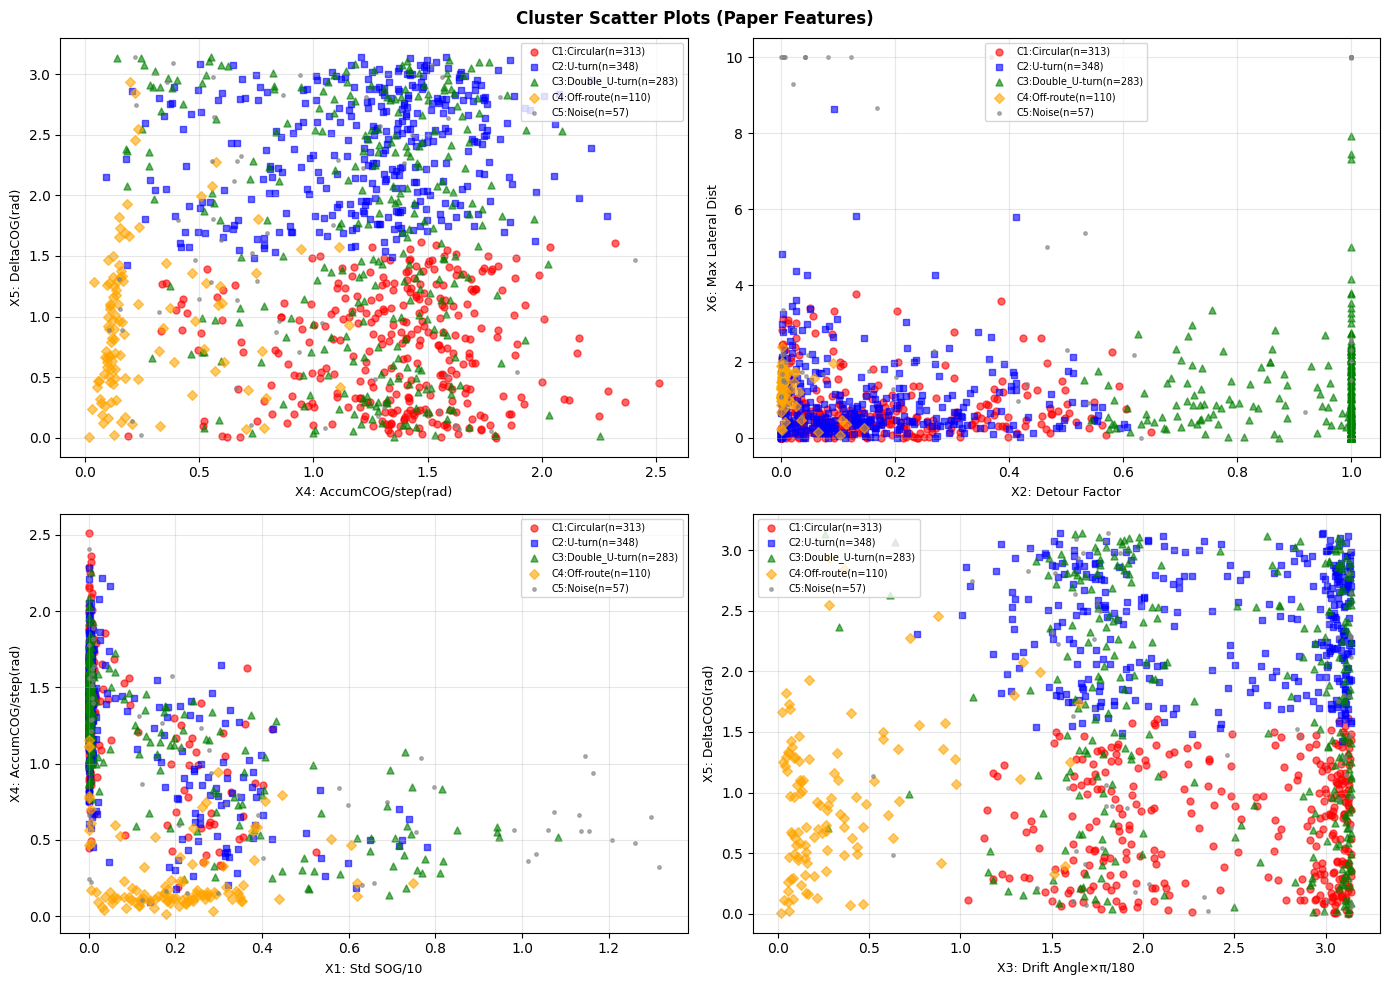

  Scatter plot saved + displayed inline


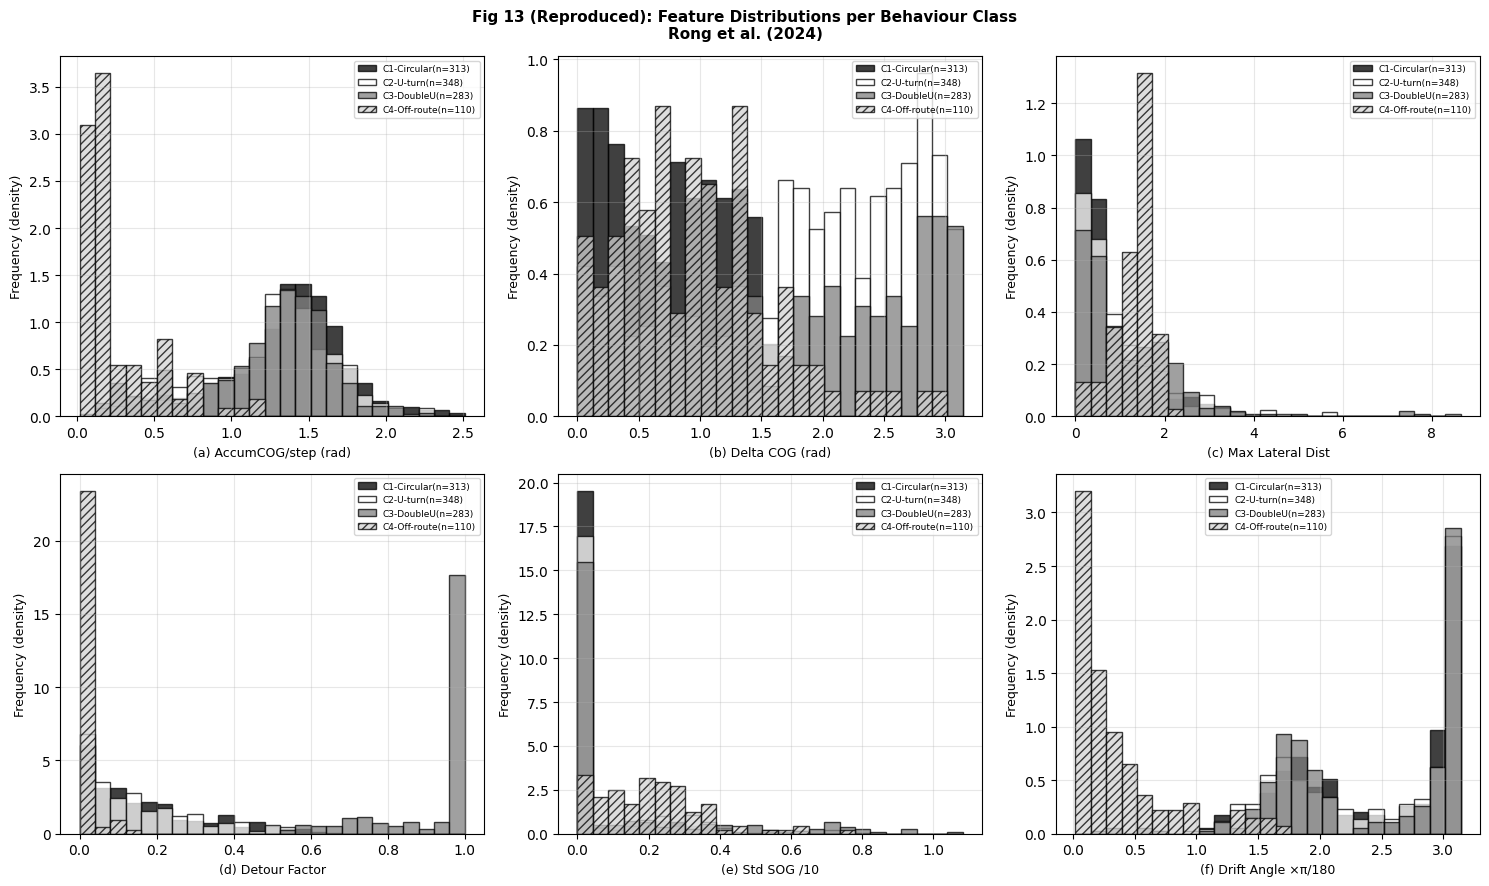

  Fig 13 distribution plot saved + displayed inline


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 8: Plots — scatter + Fig 13 distributions
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 8: Generating plots...")
print("="*60)

# Switch backend to inline for Jupyter/Colab display
import matplotlib
matplotlib.use('inline')
%matplotlib inline

colors  = {1:'red',2:'blue',3:'green',4:'orange',5:'grey'}
markers = {1:'o',2:'s',3:'^',4:'D',5:'.'}

# ── Scatter plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_pairs = [
    ('X4','X5','X4: AccumCOG/step(rad)','X5: DeltaCOG(rad)'),
    ('X2','X6','X2: Detour Factor','X6: Max Lateral Dist'),
    ('X1','X4','X1: Std SOG/10','X4: AccumCOG/step(rad)'),
    ('X3','X5','X3: Drift Angle×π/180','X5: DeltaCOG(rad)'),
]

for ax, (fx,fy,xlbl,ylbl) in zip(axes.flatten(), scatter_pairs):
    for cls in [1,2,3,4,5]:
        mask = df['class_label']==cls
        if mask.sum()==0: continue
        ax.scatter(df.loc[mask,fx], df.loc[mask,fy],
                   c=colors[cls], marker=markers[cls],
                   label=f"C{cls}:{class_names[cls]}(n={mask.sum()})",
                   alpha=0.6, s=25)
    ax.set_xlabel(xlbl, fontsize=9)
    ax.set_ylabel(ylbl, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Cluster Scatter Plots (Paper Features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'scatter_paper_features.png'),
            dpi=150, bbox_inches='tight')
plt.show()   # ← displays inline
plt.close()
print(f"  Scatter plot saved + displayed inline")

# ── Fig 13 style distributions ───────────────────────────────
FEAT_LABELS = {
    'X4':'(a) AccumCOG/step (rad)',
    'X5':'(b) Delta COG (rad)',
    'X6':'(c) Max Lateral Dist',
    'X2':'(d) Detour Factor',
    'X1':'(e) Std SOG /10',
    'X3':'(f) Drift Angle ×π/180',
}
cls_plot = [1,2,3,4]
clr_plot = ['black','white','grey','lightgrey']
hat_plot = ['','','','////']
leg_plot = ['C1-Circular','C2-U-turn','C3-DoubleU','C4-Off-route']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ai, feat in enumerate(['X4','X5','X6','X2','X1','X3']):
    ax = axes[ai]
    all_data = [df[df['class_label']==c][feat].dropna().values
                for c in cls_plot]
    combined = np.concatenate([v for v in all_data if len(v)>0])
    if len(combined)==0: continue
    bins = np.linspace(combined.min(), combined.max(), 26)
    for data,clr,hat,lbl in zip(all_data,clr_plot,hat_plot,leg_plot):
        if len(data)==0:
            ax.bar([],[],color=clr,edgecolor='k',hatch=hat,label=f'{lbl}(n=0)')
            continue
        ax.hist(data, bins=bins, density=True, alpha=0.75,
                color=clr, edgecolor='k', hatch=hat,
                label=f'{lbl}(n={len(data)})', histtype='bar')
    ax.set_xlabel(FEAT_LABELS[feat], fontsize=9)
    ax.set_ylabel('Frequency (density)', fontsize=9)
    ax.legend(fontsize=6.5)
    ax.grid(alpha=0.3)

plt.suptitle('Fig 13 (Reproduced): Feature Distributions per Behaviour Class\n'
             'Rong et al. (2024)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig13_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()   # ← displays inline
plt.close()
print(f"  Fig 13 distribution plot saved + displayed inline")

STEP 1: Loading labelled segments...
  Total segments : 1,111
  Feature cols   : ['X1_std_sog', 'X2_detour', 'X3_drift_angle', 'X4_accum_cog', 'X5_delta_cog', 'X6_max_lat']

  Class distribution:
    Class 1 (Circular       ):  313 (28.2%)
    Class 2 (U-turn         ):  348 (31.3%)
    Class 3 (Double_U-turn  ):  283 (25.5%)
    Class 4 (Off-route      ):  110 (9.9%)
    Class 5 (Noise          ):   57 (5.1%)


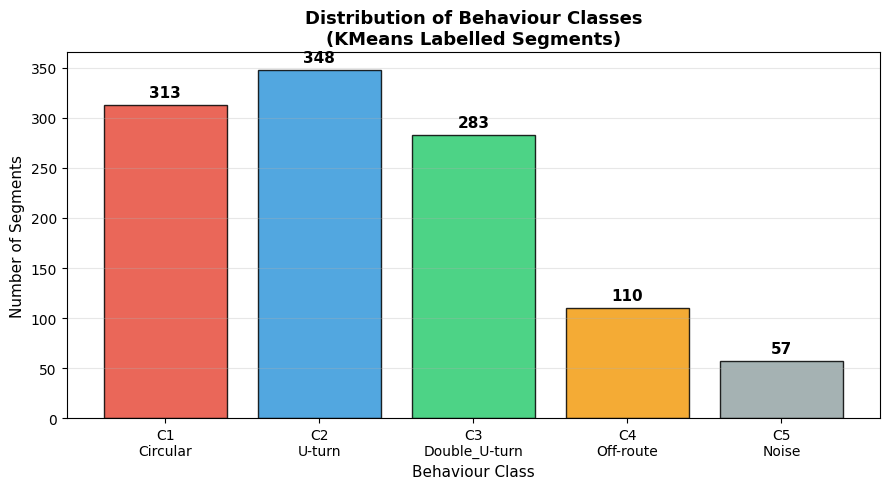

  ↑ Plot 1: Class distribution displayed

STEP 2: Preparing train/test split (75/25)...
  Train size : 833 (75%)
  Test size  : 278  (25%)

  Train class counts:
    Class 1 (Circular       ): 235
    Class 2 (U-turn         ): 261
    Class 3 (Double_U-turn  ): 212
    Class 4 (Off-route      ): 82
    Class 5 (Noise          ): 43

STEP 3: Grid search for RF hyperparameters...
  Best params found:
    max_depth                : None
    max_features             : sqrt
    min_samples_leaf         : 1
    min_samples_split        : 10
    n_estimators             : 100
  Best CV F1-macro : 0.8886

STEP 4: Training final Random Forest model...
  Test Accuracy : 0.9460 (94.6%)
  F1 (macro)    : 0.9268

  Classification Report:
               precision    recall  f1-score   support

     Circular       0.94      0.96      0.95        78
       U-turn       0.99      0.91      0.95        87
Double_U-turn       0.92      1.00      0.96        71
    Off-route       0.96      0.96      0.9

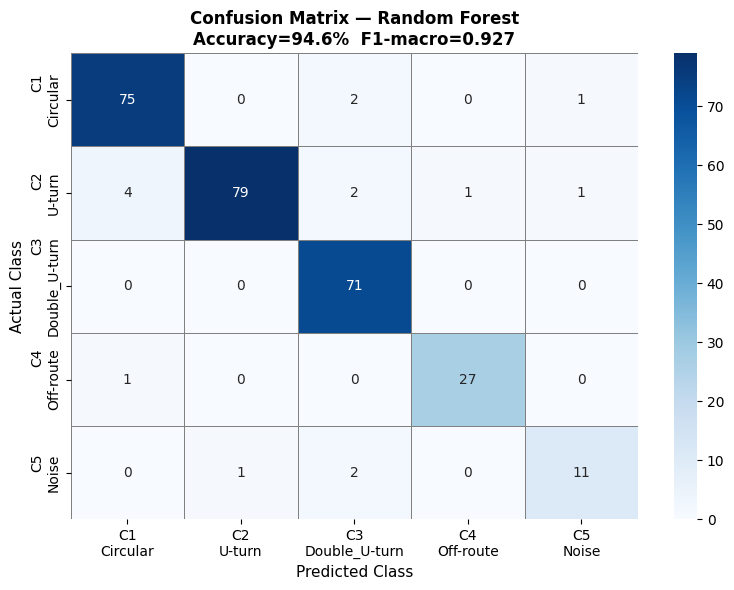

  ↑ Plot 2: Confusion matrix displayed


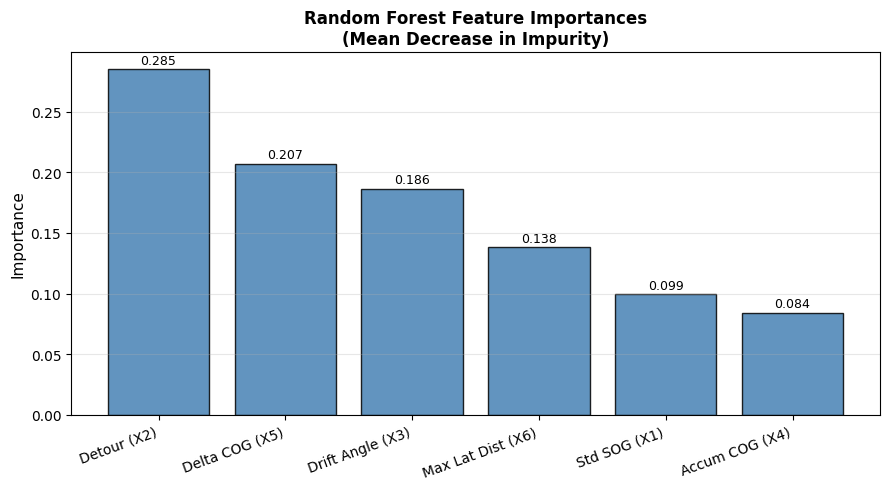

  ↑ Plot 3: Feature importance displayed

STEP 5: Computing SHAP values (Fig 14 of paper)...
  Classes in model : [1 2 3 4 5]
  SHAP values shape: (278, 6, 5)


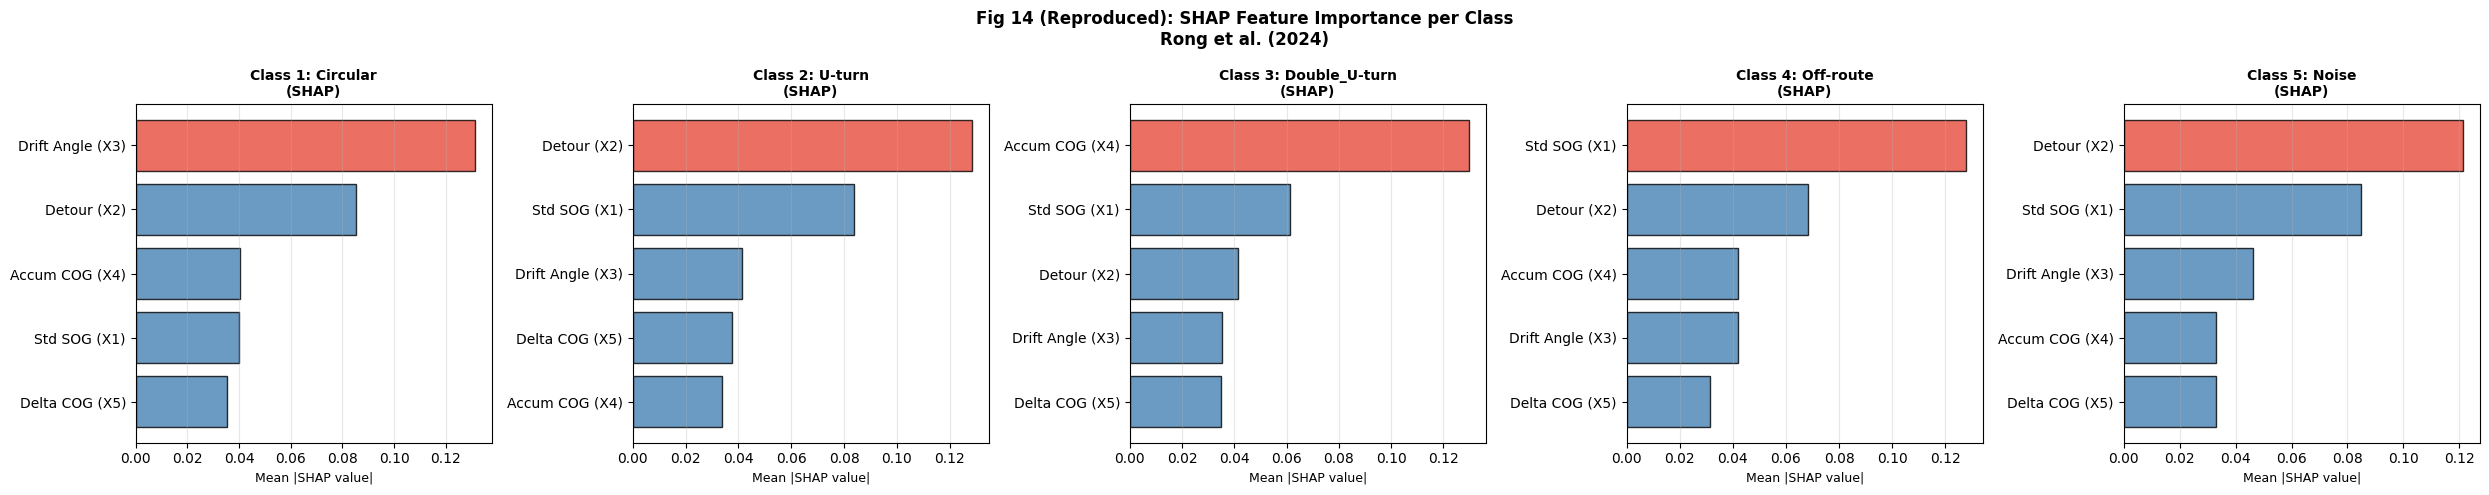

  ↑ Plot 4: SHAP per-class importance displayed


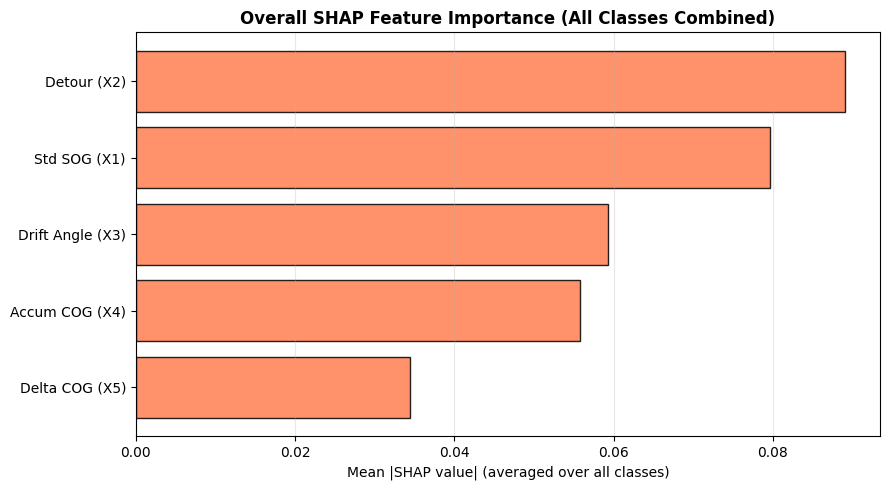

  ↑ Plot 5: Overall SHAP importance displayed


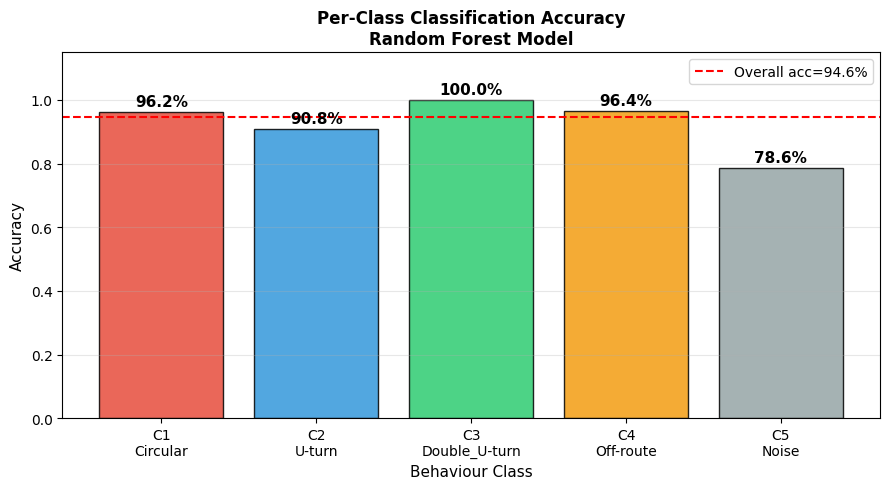

  ↑ Plot 6: Per-class accuracy displayed


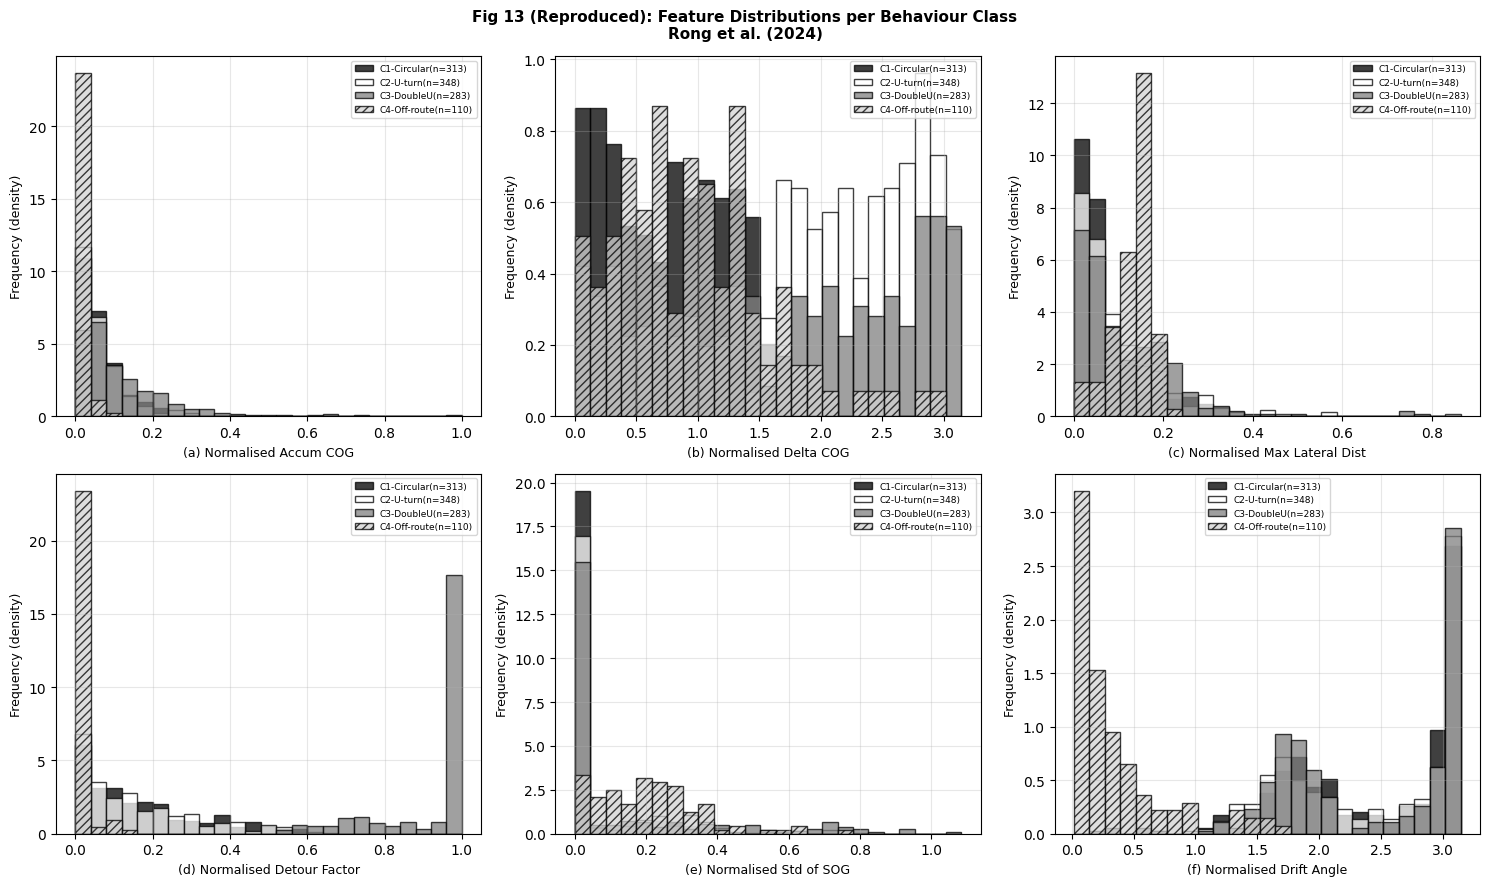

  ↑ Plot 7: Fig 13 feature distributions displayed

STEP 6: Real-time classification demo (Fig 15)...
  Demo ship MMSI : 316018851
  Segments       : 11
  Predicted classes: [4, 2, 5, 3, 1]


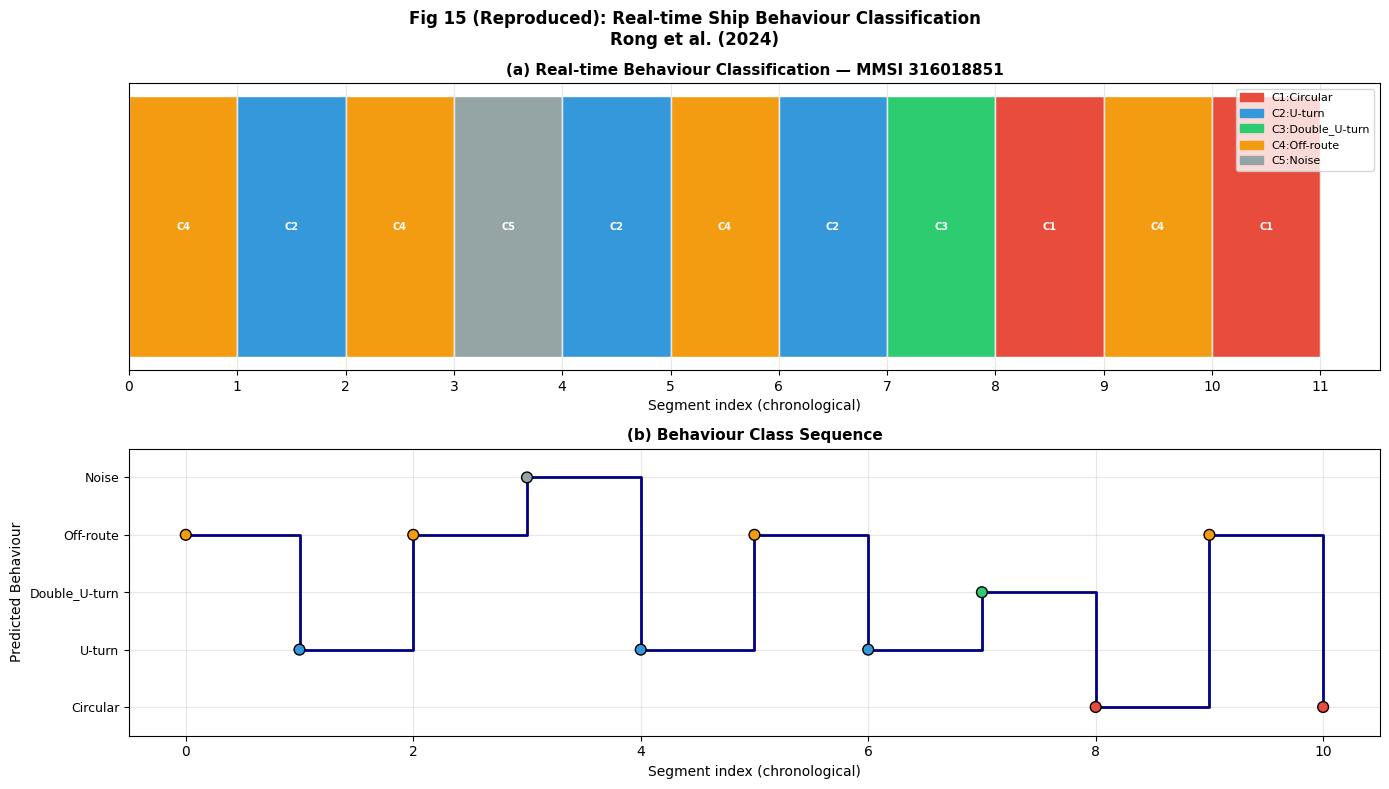

  ↑ Plot 8: Fig 15 real-time classification displayed

STEP 7: Saving results...
  Predictions saved : /content/drive/MyDrive/AIS_reduced/rf_predictions.csv
  Confusion matrix  : /content/drive/MyDrive/AIS_reduced/confusion_matrix.csv
  Feature importance: /content/drive/MyDrive/AIS_reduced/feature_importances.csv
  RF model saved    : /content/drive/MyDrive/AIS_reduced/rf_model.pkl

FINAL SUMMARY — STEP 5
  Model             : Random Forest (class_weight='balanced')
  Best params       : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
  Train/Test split  : 75% / 25%
  Test Accuracy     : 94.6%
  F1 macro          : 0.9268

  Per-class accuracy:
    Class 1 (Circular       ): 96.2%
    Class 2 (U-turn         ): 90.8%
    Class 3 (Double_U-turn  ): 100.0%
    Class 4 (Off-route      ): 96.4%
    Class 5 (Noise          ): 78.6%

  Top SHAP features (overall):
    Detour (X2)         : 0.0890
    Std SOG (X1)        : 0.07

In [ ]:
"""
=============================================================
STEP 5 : Random Forest Classification + SHAP Explainability
=============================================================
Based on: Rong et al. (2024), Section 3.2 & Section 4.3

Pipeline:
  1. Load labelled segments
  2. Train/Test split (75/25 — paper Section 4.3)
  3. Grid search for RF hyperparameters
  4. Train Random Forest classifier
  5. Confusion matrix (Table 3 of paper)
  6. SHAP values (Fig 14 of paper)
  7. Real-time prediction example (Fig 15 of paper)
  8. All plots display inline in Colab
=============================================================
"""
#import matplotlib
#matplotlib.use('inline')
#%matplotlib inline
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics         import (confusion_matrix, classification_report,
                                     accuracy_score, f1_score)
from sklearn.preprocessing   import LabelEncoder
import matplotlib.pyplot     as plt
import matplotlib.gridspec   as gridspec
import seaborn               as sns

# Install shap if not available
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH   = "/content/drive/MyDrive/AIS_reduced/abnormal_segments_labelled_final.csv"
OUTPUT_DIR   = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEATURE_COLS = ['X1_std_sog', 'X2_detour', 'X3_drift_angle',
                'X4_accum_cog', 'X5_delta_cog', 'X6_max_lat']
FEATURE_NAMES = ['Std SOG (X1)', 'Detour (X2)', 'Drift Angle (X3)',
                 'Accum COG (X4)', 'Delta COG (X5)', 'Max Lat Dist (X6)']

CLASS_NAMES  = {1:'Circular', 2:'U-turn', 3:'Double_U-turn',
                4:'Off-route', 5:'Noise'}
COLORS       = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71',
                4:'#f39c12', 5:'#95a5a6'}

RANDOM_STATE = 42
TEST_SIZE    = 0.25   # 75/25 split (paper Section 4.3)

# ─────────────────────────────────────────────────────────────
# STEP 1: Load data
# ─────────────────────────────────────────────────────────────
print("="*60)
print("STEP 1: Loading labelled segments...")
print("="*60)
df = pd.read_csv(INPUT_PATH)
print(f"  Total segments : {len(df):,}")
print(f"  Feature cols   : {FEATURE_COLS}")

# Check features exist
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing: {missing}")

print(f"\n  Class distribution:")
for cls in [1,2,3,4,5]:
    cnt = (df['class_label']==cls).sum()
    print(f"    Class {cls} ({CLASS_NAMES[cls]:15s}): {cnt:4d} ({cnt/len(df)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# PLOT 1: Class distribution bar chart (inline)
# ─────────────────────────────────────────────────────────────
class_counts = df['class_label'].value_counts().sort_index()
labels = [f"C{c}\n{CLASS_NAMES[c]}" for c in class_counts.index]
bar_colors = [COLORS[c] for c in class_counts.index]

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, class_counts.values, color=bar_colors,
               edgecolor='black', alpha=0.85)
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Distribution of Behaviour Classes\n(KMeans Labelled Segments)',
          fontsize=13, fontweight='bold')
plt.xlabel('Behaviour Class', fontsize=11)
plt.ylabel('Number of Segments', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("  ↑ Plot 1: Class distribution displayed")

# ─────────────────────────────────────────────────────────────
# STEP 2: Prepare features and labels
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 2: Preparing train/test split (75/25)...")
print("="*60)

# Use only non-noise for training (paper trains on classes 1-4)
# Class 5 (noise) is included as a test class but not trained heavily
df_train_pool = df.copy()   # include all classes

X = df_train_pool[FEATURE_COLS].values
y = df_train_pool['class_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=y   # preserve class proportions
)

print(f"  Train size : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test size  : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Train class counts:")
for cls in [1,2,3,4,5]:
    cnt = (y_train==cls).sum()
    print(f"    Class {cls} ({CLASS_NAMES[cls]:15s}): {cnt}")

# ─────────────────────────────────────────────────────────────
# STEP 3: Grid search for RF hyperparameters (paper Section 3.2)
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 3: Grid search for RF hyperparameters...")
print("="*60)

param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features'    : ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight='balanced',   # handles class imbalance
    n_jobs=-1
)

grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f"  Best params found:")
for k, v in best_params.items():
    print(f"    {k:25s}: {v}")
print(f"  Best CV F1-macro : {grid_search.best_score_:.4f}")

# ─────────────────────────────────────────────────────────────
# STEP 4: Train final RF model
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 4: Training final Random Forest model...")
print("="*60)

rf_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred, average='macro')

print(f"  Test Accuracy : {acc:.4f} ({acc*100:.1f}%)")
print(f"  F1 (macro)    : {f1:.4f}")
print(f"\n  Classification Report:")
target_names = [CLASS_NAMES[c] for c in sorted(CLASS_NAMES.keys())
                if c in np.unique(y_test)]
present_cls  = sorted(np.unique(np.concatenate([y_test, y_pred])))
print(classification_report(
    y_test, y_pred,
    labels=present_cls,
    target_names=[CLASS_NAMES[c] for c in present_cls]
))

# ─────────────────────────────────────────────────────────────
# PLOT 2: Confusion Matrix (Table 3 of paper — inline)
# ─────────────────────────────────────────────────────────────
present_cls = sorted(np.unique(np.concatenate([y_test, y_pred])))
cm = confusion_matrix(y_test, y_pred, labels=present_cls)
cm_labels = [f"C{c}\n{CLASS_NAMES[c]}" for c in present_cls]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels,
            linewidths=0.5, linecolor='grey')
plt.title(f'Confusion Matrix — Random Forest\n'
          f'Accuracy={acc*100:.1f}%  F1-macro={f1:.3f}',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=11)
plt.ylabel('Actual Class', fontsize=11)
plt.tight_layout()
plt.show()
print("  ↑ Plot 2: Confusion matrix displayed")

# ─────────────────────────────────────────────────────────────
# PLOT 3: Feature Importance (RF built-in — inline)
# ─────────────────────────────────────────────────────────────
importances = rf_model.feature_importances_
sort_idx    = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
bars = plt.bar(range(len(importances)),
               importances[sort_idx],
               color='steelblue', edgecolor='black', alpha=0.85)
plt.xticks(range(len(importances)),
           [FEATURE_NAMES[i] for i in sort_idx],
           rotation=20, ha='right', fontsize=10)
for bar, val in zip(bars, importances[sort_idx]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.title('Random Forest Feature Importances\n(Mean Decrease in Impurity)',
          fontsize=12, fontweight='bold')
plt.ylabel('Importance', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("  ↑ Plot 3: Feature importance displayed")

# ─────────────────────────────────────────────────────────────
# STEP 5: SHAP Values (Fig 14 of paper)
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 5: Computing SHAP values (Fig 14 of paper)...")
print("="*60)

# Use TreeExplainer for RF (fast)
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
# shap_values shape: (n_classes, n_samples, n_features)

classes_present = rf_model.classes_
print(f"  Classes in model : {classes_present}")
print(f"  SHAP values shape: {np.array(shap_values).shape}")

# ─────────────────────────────────────────────────────────────
# PLOT 4: SHAP Summary — per class (Fig 14 of paper — inline)
# ─────────────────────────────────────────────────────────────
n_cls_shap = len(classes_present)
fig, axes  = plt.subplots(1, n_cls_shap, figsize=(5*n_cls_shap, 5))
if n_cls_shap == 1:
    axes = [axes]

for ax_i, (cls, ax) in enumerate(zip(classes_present, axes)):
    shap_cls = shap_values[ax_i]   # (n_test, n_features)
    mean_abs = np.abs(shap_cls).mean(axis=0)
    sort_idx = np.argsort(mean_abs)[::-1]

    colors_bar = ['#e74c3c' if mean_abs[i] == mean_abs.max()
                  else 'steelblue' for i in sort_idx]
    ax.barh([FEATURE_NAMES[i] for i in sort_idx[::-1]],
            mean_abs[sort_idx[::-1]],
            color=colors_bar[::-1], edgecolor='black', alpha=0.8)
    ax.set_title(f'Class {cls}: {CLASS_NAMES.get(cls,"?")}\n(SHAP)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Fig 14 (Reproduced): SHAP Feature Importance per Class\n'
             'Rong et al. (2024)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ↑ Plot 4: SHAP per-class importance displayed")

# ─────────────────────────────────────────────────────────────
# PLOT 5: SHAP Beeswarm — overall (inline)
# ─────────────────────────────────────────────────────────────
# Aggregate SHAP across all classes (mean absolute)
shap_mean_all = np.mean([np.abs(shap_values[i])
                          for i in range(n_cls_shap)], axis=0)

plt.figure(figsize=(9, 5))
mean_feat = shap_mean_all.mean(axis=0)
sort_idx  = np.argsort(mean_feat)[::-1]
plt.barh([FEATURE_NAMES[i] for i in sort_idx[::-1]],
         mean_feat[sort_idx[::-1]],
         color='coral', edgecolor='black', alpha=0.85)
plt.title('Overall SHAP Feature Importance (All Classes Combined)',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean |SHAP value| (averaged over all classes)', fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("  ↑ Plot 5: Overall SHAP importance displayed")

# ─────────────────────────────────────────────────────────────
# PLOT 6: Per-class prediction accuracy bar chart (inline)
# ─────────────────────────────────────────────────────────────
per_class_acc = {}
for cls in present_cls:
    mask = y_test == cls
    if mask.sum() == 0:
        continue
    per_class_acc[cls] = accuracy_score(y_test[mask], y_pred[mask])

plt.figure(figsize=(9, 5))
cls_list = list(per_class_acc.keys())
acc_list = list(per_class_acc.values())
bar_clrs = [COLORS.get(c, 'steelblue') for c in cls_list]
xlabels  = [f"C{c}\n{CLASS_NAMES[c]}" for c in cls_list]

bars = plt.bar(xlabels, acc_list, color=bar_clrs,
               edgecolor='black', alpha=0.85)
for bar, val in zip(bars, acc_list):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val*100:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
plt.axhline(y=acc, color='red', linestyle='--',
            label=f'Overall acc={acc*100:.1f}%')
plt.ylim(0, 1.15)
plt.title('Per-Class Classification Accuracy\nRandom Forest Model',
          fontsize=12, fontweight='bold')
plt.xlabel('Behaviour Class', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("  ↑ Plot 6: Per-class accuracy displayed")

# ─────────────────────────────────────────────────────────────
# PLOT 7: Feature distributions per class (Fig 13 paper — inline)
# ─────────────────────────────────────────────────────────────
df_labelled = df.copy()
cls_plot    = [1,2,3,4]
clr_plot    = ['black','white','grey','lightgrey']
hat_plot    = ['','','','////']
leg_plot    = ['C1-Circular','C2-U-turn','C3-DoubleU','C4-Off-route']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

feat_plot_order = ['X4_accum_cog','X5_delta_cog','X6_max_lat',
                   'X2_detour','X1_std_sog','X3_drift_angle']
feat_xlabels    = {
    'X4_accum_cog'  : '(a) Normalised Accum COG',
    'X5_delta_cog'  : '(b) Normalised Delta COG',
    'X6_max_lat'    : '(c) Normalised Max Lateral Dist',
    'X2_detour'     : '(d) Normalised Detour Factor',
    'X1_std_sog'    : '(e) Normalised Std of SOG',
    'X3_drift_angle': '(f) Normalised Drift Angle',
}

for ai, feat in enumerate(feat_plot_order):
    ax = axes[ai]
    all_data = [df_labelled[df_labelled['class_label']==c][feat].dropna().values
                for c in cls_plot]
    combined = np.concatenate([v for v in all_data if len(v)>0])
    if len(combined)==0: continue
    bins = np.linspace(combined.min(), combined.max(), 26)

    for data, clr, hat, lbl in zip(all_data, clr_plot, hat_plot, leg_plot):
        if len(data)==0:
            ax.bar([],[],color=clr,edgecolor='k',hatch=hat,
                   label=f'{lbl}(n=0)')
            continue
        ax.hist(data, bins=bins, density=True, alpha=0.75,
                color=clr, edgecolor='k', hatch=hat,
                label=f'{lbl}(n={len(data)})', histtype='bar')
    ax.set_xlabel(feat_xlabels.get(feat,feat), fontsize=9)
    ax.set_ylabel('Frequency (density)', fontsize=9)
    ax.legend(fontsize=6.5)
    ax.grid(alpha=0.3)

plt.suptitle('Fig 13 (Reproduced): Feature Distributions per Behaviour Class\n'
             'Rong et al. (2024)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ↑ Plot 7: Fig 13 feature distributions displayed")

# ─────────────────────────────────────────────────────────────
# PLOT 8: Real-time classification demo (Fig 15 style — inline)
# ─────────────────────────────────────────────────────────────
# Predict on all segments and show behaviour over time for top ship
print("\n"+"="*60)
print("STEP 6: Real-time classification demo (Fig 15)...")
print("="*60)

# Predict for all segments
df_labelled['rf_pred'] = rf_model.predict(df_labelled[FEATURE_COLS].values)
df_labelled['rf_pred_name'] = df_labelled['rf_pred'].map(CLASS_NAMES)

# Pick ship with most diverse predictions
ship_diversity = df_labelled.groupby('MMSI')['rf_pred'].nunique()
demo_mmsi      = ship_diversity.idxmax()
demo_df        = df_labelled[df_labelled['MMSI']==demo_mmsi].copy()
demo_df['t_start'] = pd.to_datetime(demo_df['t_start'])
demo_df = demo_df.sort_values('t_start').reset_index(drop=True)

print(f"  Demo ship MMSI : {demo_mmsi}")
print(f"  Segments       : {len(demo_df)}")
print(f"  Predicted classes: {demo_df['rf_pred'].unique().tolist()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel a: predicted class over time
ax = axes[0]
cls_color_map = {1:'#e74c3c',2:'#3498db',3:'#2ecc71',4:'#f39c12',5:'#95a5a6'}
t_idx = range(len(demo_df))
for i, (_, seg) in enumerate(demo_df.iterrows()):
    cls = seg['rf_pred']
    ax.barh(0, 1, left=i, color=cls_color_map.get(cls,'grey'),
            height=0.5, edgecolor='white')
    ax.text(i+0.5, 0, f"C{cls}", ha='center', va='center',
            fontsize=7, color='white', fontweight='bold')

from matplotlib.patches import Patch
legend_patches = [Patch(color=cls_color_map[c],
                        label=f'C{c}:{CLASS_NAMES[c]}')
                  for c in [1,2,3,4,5] if c in df_labelled['rf_pred'].values]
ax.legend(handles=legend_patches, loc='upper right', fontsize=8)
ax.set_yticks([])
ax.set_xticks(range(0, len(demo_df)+1, max(1, len(demo_df)//10)))
ax.set_xlabel('Segment index (chronological)', fontsize=10)
ax.set_title(f'(a) Real-time Behaviour Classification — MMSI {demo_mmsi}',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Panel b: class label timeline as step plot
ax = axes[1]
ax.step(range(len(demo_df)), demo_df['rf_pred'].values,
        where='post', linewidth=2, color='navy')
ax.scatter(range(len(demo_df)), demo_df['rf_pred'].values,
           c=[cls_color_map.get(c,'grey') for c in demo_df['rf_pred']],
           s=60, zorder=5, edgecolors='black')
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels([CLASS_NAMES[c] for c in [1,2,3,4,5]], fontsize=9)
ax.set_xlabel('Segment index (chronological)', fontsize=10)
ax.set_ylabel('Predicted Behaviour', fontsize=10)
ax.set_title('(b) Behaviour Class Sequence', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 5.5)

plt.suptitle('Fig 15 (Reproduced): Real-time Ship Behaviour Classification\n'
             'Rong et al. (2024)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ↑ Plot 8: Fig 15 real-time classification displayed")

# ─────────────────────────────────────────────────────────────
# STEP 7: Save model and results
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 7: Saving results...")
print("="*60)

# Save predictions
pred_path = os.path.join(OUTPUT_DIR, "rf_predictions.csv")
df_labelled.to_csv(pred_path, index=False)
print(f"  Predictions saved : {pred_path}")

# Save confusion matrix as CSV (Table 3)
cm_df = pd.DataFrame(
    cm,
    index=[f'Actual_C{c}' for c in present_cls],
    columns=[f'Pred_C{c}' for c in present_cls]
)
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.csv")
cm_df.to_csv(cm_path)
print(f"  Confusion matrix  : {cm_path}")

# Save feature importances
fi_df = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': importances
}).sort_values('Importance', ascending=False)
fi_path = os.path.join(OUTPUT_DIR, "feature_importances.csv")
fi_df.to_csv(fi_path, index=False)
print(f"  Feature importance: {fi_path}")

# Save RF model
try:
    import joblib
    model_path = os.path.join(OUTPUT_DIR, "rf_model.pkl")
    joblib.dump(rf_model, model_path)
    print(f"  RF model saved    : {model_path}")
except Exception as e:
    print(f"  Model save skipped: {e}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("FINAL SUMMARY — STEP 5")
print("="*60)
print(f"  Model             : Random Forest (class_weight='balanced')")
print(f"  Best params       : {best_params}")
print(f"  Train/Test split  : 75% / 25%")
print(f"  Test Accuracy     : {acc*100:.1f}%")
print(f"  F1 macro          : {f1:.4f}")
print(f"\n  Per-class accuracy:")
for cls, a in per_class_acc.items():
    print(f"    Class {cls} ({CLASS_NAMES[cls]:15s}): {a*100:.1f}%")

print(f"\n  Top SHAP features (overall):")
mean_feat_imp = shap_mean_all.mean(axis=0)
for i in np.argsort(mean_feat_imp)[::-1]:
    print(f"    {FEATURE_NAMES[i]:20s}: {mean_feat_imp[i]:.4f}")

print(f"\n  Plots shown inline (8 total):")
print(f"    1. Class distribution bar chart")
print(f"    2. Confusion matrix heatmap (Table 3)")
print(f"    3. RF feature importances")
print(f"    4. SHAP per-class importance (Fig 14)")
print(f"    5. Overall SHAP importance")
print(f"    6. Per-class accuracy")
print(f"    7. Feature distributions (Fig 13)")
print(f"    8. Real-time classification (Fig 15)")
print(f"\n  ✅ Implementation of Rong et al. (2024) complete!")
print("="*60)

Loading data and model...
  Loaded: 1111 segments | acc=94.6% | F1=0.9268

SECTION A: OVERFITTING DIAGNOSTICS

  A1. Train vs Test Accuracy Gap:
      Train accuracy : 98.92%
      Test accuracy  : 94.60%
      Gap            : 4.32%
      → ✅ Gap < 5% — NO significant overfitting

  A2. 5-Fold Stratified Cross-Validation:
      CV Accuracy : 94.87% ± 0.92%
      CV F1 macro : 0.9115 ± 0.0318
      All fold accs: ['93.3%', '94.6%', '95.5%', '95.9%', '95.0%']
      → ✅ Low std — model is stable across folds

  Computing learning curves (this takes ~1-2 min)...


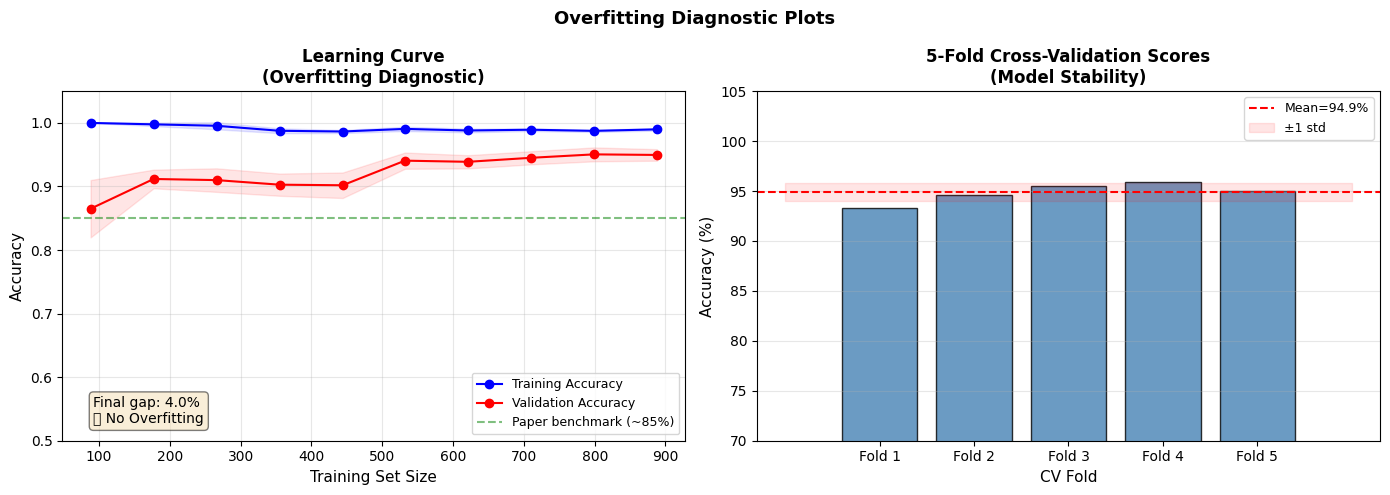

  ↑ Plot A1: Learning curves displayed


In [5]:


import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     learning_curve, cross_val_score)
from sklearn.metrics         import (confusion_matrix, accuracy_score,
                                     f1_score, roc_auc_score,
                                     classification_report)
from sklearn.preprocessing   import label_binarize
import joblib, os

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH  = "/content/drive/MyDrive/AIS_reduced/abnormal_segments_labelled_final.csv"
MODEL_PATH  = "/content/drive/MyDrive/AIS_reduced/rf_model.pkl"
OUTPUT_DIR  = "/content/drive/MyDrive/AIS_reduced"

FEATURE_COLS  = ['X1_std_sog','X2_detour','X3_drift_angle',
                 'X4_accum_cog','X5_delta_cog','X6_max_lat']
FEATURE_NAMES = ['Std SOG','Detour','Drift Angle',
                 'Accum COG','Delta COG','Max Lat Dist']
CLASS_NAMES   = {1:'Circular',2:'U-turn',3:'Double_U-turn',
                 4:'Off-route',5:'Noise'}
COLORS        = {1:'#e74c3c',2:'#3498db',3:'#2ecc71',
                 4:'#f39c12',5:'#95a5a6'}
RANDOM_STATE  = 42

# ─────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────
print("="*60)
print("Loading data and model...")
print("="*60)
df       = pd.read_csv(INPUT_PATH)
rf_model = joblib.load(MODEL_PATH)

X = df[FEATURE_COLS].values
y = df['class_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

y_pred     = rf_model.predict(X_test)
y_pred_all = rf_model.predict(X)
acc        = accuracy_score(y_test, y_pred)
f1         = f1_score(y_test, y_pred, average='macro')
print(f"  Loaded: {len(df)} segments | acc={acc*100:.1f}% | F1={f1:.4f}")

# ═════════════════════════════════════════════════════════════
# SECTION A: OVERFITTING DIAGNOSTICS
# ═════════════════════════════════════════════════════════════
print("\n"+"="*60)
print("SECTION A: OVERFITTING DIAGNOSTICS")
print("="*60)

# A1: Train vs Test accuracy gap
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)
gap       = train_acc - test_acc

print(f"\n  A1. Train vs Test Accuracy Gap:")
print(f"      Train accuracy : {train_acc*100:.2f}%")
print(f"      Test accuracy  : {test_acc*100:.2f}%")
print(f"      Gap            : {gap*100:.2f}%")
if gap < 0.05:
    print(f"      → ✅ Gap < 5% — NO significant overfitting")
elif gap < 0.10:
    print(f"      → ⚠  Gap 5-10% — Mild overfitting")
else:
    print(f"      → ❌ Gap > 10% — Significant overfitting")

# A2: Cross-validation scores (5-fold)
print(f"\n  A2. 5-Fold Stratified Cross-Validation:")
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_accs = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1s  = cross_val_score(rf_model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"      CV Accuracy : {cv_accs.mean()*100:.2f}% ± {cv_accs.std()*100:.2f}%")
print(f"      CV F1 macro : {cv_f1s.mean():.4f} ± {cv_f1s.std():.4f}")
print(f"      All fold accs: {[f'{a*100:.1f}%' for a in cv_accs]}")
if cv_accs.std() < 0.03:
    print(f"      → ✅ Low std — model is stable across folds")
else:
    print(f"      → ⚠  High std — model may be sensitive to data split")
#─────────────────────────────────────────────────────────────
# PLOT A1: Learning Curves (train size vs accuracy)
# ─────────────────────────────────────────────────────────────
print(f"\n  Computing learning curves (this takes ~1-2 min)...")
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curve
ax = axes[0]
ax.plot(train_sizes, train_mean, 'o-', color='blue',
        label='Training Accuracy')
ax.fill_between(train_sizes, train_mean-train_std,
                train_mean+train_std, alpha=0.1, color='blue')
ax.plot(train_sizes, val_mean, 'o-', color='red',
        label='Validation Accuracy')
ax.fill_between(train_sizes, val_mean-val_std,
                val_mean+val_std, alpha=0.1, color='red')
ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.5,
           label='Paper benchmark (~85%)')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Learning Curve\n(Overfitting Diagnostic)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.05)

final_gap = train_mean[-1] - val_mean[-1]
verdict = "✅ No Overfitting" if final_gap < 0.05 else "⚠ Mild Overfitting"
ax.text(0.05, 0.05, f'Final gap: {final_gap*100:.1f}%\n{verdict}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# CV score distribution
ax = axes[1]
ax.bar(['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5'],
       cv_accs * 100, color='steelblue', edgecolor='black', alpha=0.8)
ax.axhline(y=cv_accs.mean()*100, color='red', linestyle='--',
           label=f'Mean={cv_accs.mean()*100:.1f}%')
ax.fill_between(range(-1,6),
                (cv_accs.mean()-cv_accs.std())*100,
                (cv_accs.mean()+cv_accs.std())*100,
                alpha=0.1, color='red', label='±1 std')
ax.set_xlabel('CV Fold', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('5-Fold Cross-Validation Scores\n(Model Stability)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(70, 105)

plt.suptitle('Overfitting Diagnostic Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ↑ Plot A1: Learning curves displayed")